### Dimensjonering av magasin og kostnad

In [1]:
#Import av nødvendige pakker

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import math

#### Magasinstørrelse og tverrsnittsareal

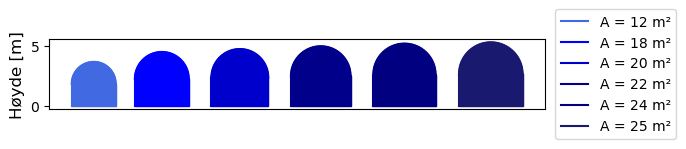

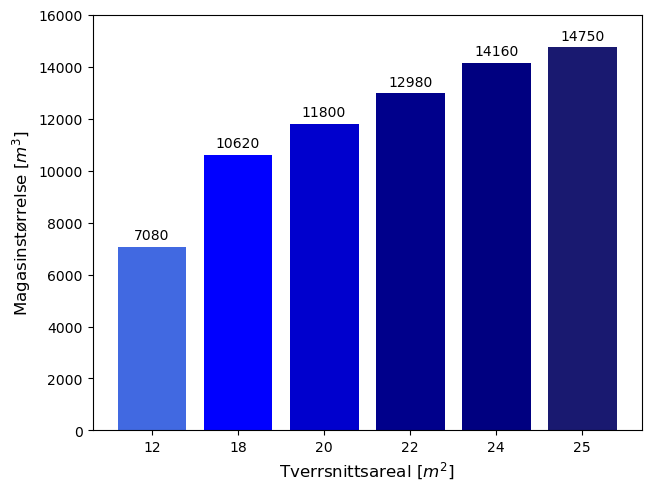

In [2]:
#Lengde tunnel
L = 590 #m

A_org = 12 #m^2

A1 = 18 #m^2
A2 = 20 #m^2
A3 = 22 #m^2
A4 = 24 #m^2
A5 = 25 #m^2


M_org = A_org*L #m^3
M1 = A1*L #m^3
M2 = A2*L #m^3
M3 = A3*L #m^3
M4 = A4*L #m^3
M5 = A5*L #m^3

#Grafisk fremstilling av tverrsnittsareal
arealer = [A_org, A1, A2, A3, A4, A5] # m²
                
farger = ['royalblue', 'blue', 'mediumblue', 'darkblue', 'navy', 'midnightblue']

theta = np.linspace(np.pi, 0, 300)

fig, ax = plt.subplots()

x_offset = 0.0                 # forskyvning mellom profilene
luft = 2.0                     # avstand mellom tverrsnitt

for A, farge in zip(arealer, farger):
    radius = np.sqrt(A*2/(4 + np.pi))
    bredde = 2*radius
    h = radius

    # Rektangel (vegg)
    x_rect = [
        x_offset - bredde/2,
        x_offset + bredde/2,
        x_offset + bredde/2,
        x_offset - bredde/2,
        x_offset - bredde/2
    ]
    y_rect = [0, 0, h, h, 0]

    # Hvelv (halvsirkel)
    x_arc = x_offset + radius * np.cos(theta)
    y_arc = h + radius * np.sin(theta)

    # Tegn kontur
    ax.plot(x_rect, y_rect, color=farge)
    ax.plot(x_arc, y_arc, color=farge, label=f"A = {round(A, 1)} m²")
   

    # Fyll tverrsnittet (valgfritt)
    ax.fill(x_rect, y_rect, color=farge)
    ax.fill(x_arc, y_arc, color=farge)

    # Flytt neste tverrsnitt
    x_offset += bredde + luft


ax.set_aspect("equal")
#ax.set_xlabel("Bredde [m]")
ax.set_xticks([])
ax.set_ylabel("Høyde [m]",fontsize =12)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)
plt.show()

#Grafisk fremstilling av magasinstørrelse

M = [M_org, M1, M2, M3, M4, M5]

arealer_M = [A_org, A1, A2, A3, A4, A5]

farger_M = ['royalblue', 'blue', 'mediumblue', 'darkblue', 'navy', 'midnightblue']

x = np.arange(len(arealer_M))

fig, ax = plt.subplots(layout='constrained')

ax.bar(x, M, color=farger_M)
ax.bar_label(ax.containers[0], padding=3)

ax.set_ylabel('Magasinstørrelse [$m^3$]', fontsize = 12)
ax.set_xlabel('Tverrsnittsareal [$m^2$]', fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(arealer_M)
ax.set_ylim(0, 16000)


plt.show()

#### Kostnadsberegninger

Kostnad for tunnel blir 23566 kr/m ved A = 12
Kostnad for tunnel blir 25475 kr/m ved A = 18
Kostnad for tunnel blir 26111 kr/m ved A = 20
Kostnad for tunnel blir 26747 kr/m ved A = 22
Kostnad for tunnel blir 27383 kr/m ved A = 24
Kostnad for tunnel blir 27701 kr/m ved A = 25


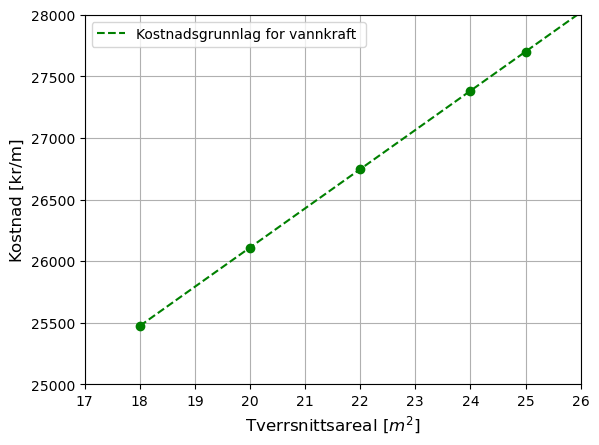

In [8]:

#Kostnadsgrunnklag for vannkraft (fra 18 m^2)
x = np.arange(18, 51)

def y(x):
    return (196.3*x + 12187)*0.96*1.688

plt.plot(x, y(x), color='green', linestyle='--', label="Kostnadsgrunnlag for vannkraft ")

for A in arealer:
        plt.plot(A, y(A), 'o', color='green')
        print(f"Kostnad for tunnel blir {round(y(A))} kr/m ved A = {A}")


plt.xlabel('Tverrsnittsareal [$m^2$]', fontsize = 12)
plt.ylabel('Kostnad [kr/m]', fontsize = 12)

plt.xlim(17, 26)
plt.ylim(25000, 28000)
plt.legend()
plt.grid()
plt.show()

